# Notebook 01 — PPO-MLP from scratch sur CartPole-v1

**Objectif :** implémenter PPO (Schulman et al., 2017) avec MLP, *from scratch*, et valider sur `CartPole-v1`.

**Référence d'implémentation :** [CleanRL](https://github.com/vwxyzjn/cleanrl) `ppo.py` (Huang et al., 2022) — code **réécrit** et commenté en français.

**Critère de réussite :** retour moyen ≥ 475 (résolu à 475/500) en < 100k timesteps.

## Concepts PPO

PPO optimise une politique stochastique $\pi_\theta(a|s)$ avec un *clipping* du ratio de probabilités :

$$L^{CLIP}(\theta) = \mathbb{E}_t\left[\min\left(r_t(\theta)\hat{A}_t,\; \text{clip}(r_t(\theta), 1-\epsilon, 1+\epsilon)\hat{A}_t\right)\right]$$

où $r_t(\theta) = \pi_\theta(a_t|s_t)/\pi_{\theta_{old}}(a_t|s_t)$ et $\hat{A}_t$ est l'avantage estimé par **GAE**.

## Installation (Colab uniquement)

In [19]:
# !pip install -q gymnasium torch numpy matplotlib tensorboard

## Setup chemins (pour importer `src/`)

In [20]:
import sys
from pathlib import Path
# Le notebook est dans notebooks/, on remonte d'un cran pour atteindre src/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
print(f"ROOT = {ROOT}")

ROOT = c:\Users\Pape Malick\works\ppo-recurrent-pomdp


## Code PPO-MLP (cellule unique pour la lisibilité)

Cellule longue mais structurée par sections : `Args` → seeding → `AgentMLP` → `train_ppo_mlp`.

In [21]:
import os, random, time, json
from dataclasses import dataclass, asdict
from pathlib import Path

import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions.categorical import Categorical
import matplotlib.pyplot as plt


@dataclass
class Args:
    exp_name: str = "ppo_mlp"
    seed: int = 1
    cuda: bool = True
    env_id: str = "CartPole-v1"
    total_timesteps: int = 100_000
    learning_rate: float = 2.5e-4
    anneal_lr: bool = True
    num_envs: int = 4
    num_steps: int = 128
    gamma: float = 0.99
    gae_lambda: float = 0.95
    num_minibatches: int = 4
    update_epochs: int = 4
    norm_adv: bool = True
    clip_coef: float = 0.2
    clip_vloss: bool = True
    ent_coef: float = 0.01
    vf_coef: float = 0.5
    max_grad_norm: float = 0.5
    use_masked_velocity: bool = False  # passe à True pour le POMDP

    @property
    def batch_size(self): return self.num_envs * self.num_steps
    @property
    def minibatch_size(self): return self.batch_size // self.num_minibatches
    @property
    def num_iterations(self): return self.total_timesteps // self.batch_size


def set_global_seed(seed, det=True):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = det; torch.backends.cudnn.benchmark = not det
    os.environ.setdefault("PYTHONHASHSEED", str(seed))


def layer_init(layer, std=np.sqrt(2), bias_const=0.0):
    torch.nn.init.orthogonal_(layer.weight, std)
    torch.nn.init.constant_(layer.bias, bias_const)
    return layer


class AgentMLP(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden_size=64):
        super().__init__()
        self.critic = nn.Sequential(
            layer_init(nn.Linear(obs_dim, hidden_size)), nn.Tanh(),
            layer_init(nn.Linear(hidden_size, hidden_size)), nn.Tanh(),
            layer_init(nn.Linear(hidden_size, 1), std=1.0),
        )
        self.actor = nn.Sequential(
            layer_init(nn.Linear(obs_dim, hidden_size)), nn.Tanh(),
            layer_init(nn.Linear(hidden_size, hidden_size)), nn.Tanh(),
            layer_init(nn.Linear(hidden_size, n_actions), std=0.01),
        )
    def get_value(self, x): return self.critic(x)
    def get_action_and_value(self, x, action=None):
        logits = self.actor(x)
        dist = Categorical(logits=logits)
        if action is None: action = dist.sample()
        return action, dist.log_prob(action), dist.entropy(), self.critic(x)


def make_env(env_id, seed, idx, use_masked_velocity=False):
    def thunk():
        env = gym.make(env_id)
        if use_masked_velocity:
            from src.envs.pomdp_wrappers import MaskVelocityWrapper
            env = MaskVelocityWrapper(env)
        env = gym.wrappers.RecordEpisodeStatistics(env)
        env.action_space.seed(seed + idx)
        return env
    return thunk


def train_ppo_mlp(args, run_name):
    set_global_seed(args.seed)
    device = torch.device("cuda" if args.cuda and torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")

    envs = gym.vector.SyncVectorEnv([
        make_env(args.env_id, args.seed, i, args.use_masked_velocity)
        for i in range(args.num_envs)
    ])
    obs_shape = envs.single_observation_space.shape
    n_actions = envs.single_action_space.n
    obs_dim = int(np.prod(obs_shape))
    print(f"obs_shape={obs_shape}, n_actions={n_actions}")

    agent = AgentMLP(obs_dim, n_actions).to(device)
    optimizer = optim.Adam(agent.parameters(), lr=args.learning_rate, eps=1e-5)

    obs_buf = torch.zeros((args.num_steps, args.num_envs) + obs_shape, device=device)
    actions_buf = torch.zeros((args.num_steps, args.num_envs), device=device)
    logprobs_buf = torch.zeros((args.num_steps, args.num_envs), device=device)
    rewards_buf = torch.zeros((args.num_steps, args.num_envs), device=device)
    dones_buf = torch.zeros((args.num_steps, args.num_envs), device=device)
    values_buf = torch.zeros((args.num_steps, args.num_envs), device=device)

    history = {"step": [], "episodic_return": []}
    global_step = 0
    start = time.time()
    next_obs, _ = envs.reset(seed=args.seed)
    next_obs = torch.tensor(next_obs, dtype=torch.float32, device=device)
    next_done = torch.zeros(args.num_envs, device=device)

    for iteration in range(1, args.num_iterations + 1):
        if args.anneal_lr:
            frac = 1.0 - (iteration - 1) / args.num_iterations
            for pg in optimizer.param_groups: pg["lr"] = frac * args.learning_rate

        for step in range(args.num_steps):
            global_step += args.num_envs
            obs_buf[step] = next_obs
            dones_buf[step] = next_done
            with torch.no_grad():
                action, logprob, _, value = agent.get_action_and_value(next_obs)
                values_buf[step] = value.flatten()
            actions_buf[step] = action
            logprobs_buf[step] = logprob
            obs_np, reward, term, trunc, info = envs.step(action.cpu().numpy())
            rewards_buf[step] = torch.tensor(reward, dtype=torch.float32, device=device)
            done_np = np.logical_or(term, trunc)
            next_obs = torch.tensor(obs_np, dtype=torch.float32, device=device)
            next_done = torch.tensor(done_np, dtype=torch.float32, device=device)
            # Logging compatible Gymnasium 0.29 et 1.x
            if "final_info" in info:
                for env_info in info["final_info"]:
                    if env_info and "episode" in env_info:
                        history["step"].append(global_step)
                        history["episodic_return"].append(float(env_info["episode"]["r"]))
            elif "episode" in info and "_episode" in info:
                mask = info["_episode"]
                if np.any(mask):
                    for idx in np.where(mask)[0]:
                        history["step"].append(global_step)
                        history["episodic_return"].append(float(info["episode"]["r"][idx]))

        with torch.no_grad():
            next_value = agent.get_value(next_obs).reshape(1, -1)
            advantages = torch.zeros_like(rewards_buf)
            lastgaelam = 0.0
            for t in reversed(range(args.num_steps)):
                if t == args.num_steps - 1:
                    nextnonterm = 1.0 - next_done; nextvals = next_value
                else:
                    nextnonterm = 1.0 - dones_buf[t+1]; nextvals = values_buf[t+1]
                delta = rewards_buf[t] + args.gamma * nextvals * nextnonterm - values_buf[t]
                advantages[t] = lastgaelam = delta + args.gamma * args.gae_lambda * nextnonterm * lastgaelam
            returns = advantages + values_buf

        b_obs = obs_buf.reshape((-1,) + obs_shape)
        b_logprobs = logprobs_buf.reshape(-1)
        b_actions = actions_buf.reshape(-1).long()
        b_advantages = advantages.reshape(-1)
        b_returns = returns.reshape(-1)
        b_values = values_buf.reshape(-1)
        b_inds = np.arange(args.batch_size)

        for epoch in range(args.update_epochs):
            np.random.shuffle(b_inds)
            for s in range(0, args.batch_size, args.minibatch_size):
                mb = b_inds[s:s+args.minibatch_size]
                _, newlogprob, entropy, newvalue = agent.get_action_and_value(b_obs[mb], b_actions[mb])
                logratio = newlogprob - b_logprobs[mb]
                ratio = logratio.exp()
                mb_adv = b_advantages[mb]
                if args.norm_adv:
                    mb_adv = (mb_adv - mb_adv.mean()) / (mb_adv.std() + 1e-8)
                pg_loss1 = -mb_adv * ratio
                pg_loss2 = -mb_adv * torch.clamp(ratio, 1-args.clip_coef, 1+args.clip_coef)
                pg_loss = torch.max(pg_loss1, pg_loss2).mean()
                newvalue = newvalue.view(-1)
                if args.clip_vloss:
                    v_clipped = b_values[mb] + torch.clamp(newvalue - b_values[mb], -args.clip_coef, args.clip_coef)
                    v_loss = 0.5 * torch.max((newvalue - b_returns[mb])**2, (v_clipped - b_returns[mb])**2).mean()
                else:
                    v_loss = 0.5 * ((newvalue - b_returns[mb])**2).mean()
                ent_loss = entropy.mean()
                loss = pg_loss - args.ent_coef * ent_loss + args.vf_coef * v_loss
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(agent.parameters(), args.max_grad_norm)
                optimizer.step()

        if iteration % 20 == 0 or iteration == 1:
            recent = history["episodic_return"][-20:] if history["episodic_return"] else [0]
            sps = int(global_step / (time.time() - start))
            print(f"iter {iteration:4d} | step {global_step:7d} | return(20)={np.mean(recent):6.1f} | SPS={sps}")

    envs.close()
    print(f"\nDurée totale : {time.time()-start:.1f}s")
    return agent, history


## Entraînement sur CartPole-v1 (MDP complet)

In [22]:
args = Args(
    exp_name="ppo_mlp_cartpole_full",
    env_id="CartPole-v1",
    use_masked_velocity=False,
    total_timesteps=300_000,
    seed=1,
)
run_name = f"{args.exp_name}__seed{args.seed}"
agent, history = train_ppo_mlp(args, run_name)

Device: cpu
obs_shape=(4,), n_actions=2
iter    1 | step     512 | return(20)=  20.1 | SPS=1443
iter   20 | step   10240 | return(20)=  89.1 | SPS=2945
iter   40 | step   20480 | return(20)= 196.9 | SPS=3345
iter   60 | step   30720 | return(20)= 202.4 | SPS=3511
iter   80 | step   40960 | return(20)= 278.8 | SPS=3617
iter  100 | step   51200 | return(20)= 274.4 | SPS=3690
iter  120 | step   61440 | return(20)= 280.0 | SPS=3744
iter  140 | step   71680 | return(20)= 359.9 | SPS=3776
iter  160 | step   81920 | return(20)= 386.6 | SPS=3806
iter  180 | step   92160 | return(20)= 349.9 | SPS=3826
iter  200 | step  102400 | return(20)= 432.4 | SPS=3831
iter  220 | step  112640 | return(20)= 338.6 | SPS=3849
iter  240 | step  122880 | return(20)= 361.4 | SPS=3859
iter  260 | step  133120 | return(20)= 374.0 | SPS=3857
iter  280 | step  143360 | return(20)= 453.1 | SPS=3865
iter  300 | step  153600 | return(20)= 434.9 | SPS=3872
iter  320 | step  163840 | return(20)= 352.7 | SPS=3881
iter  34

## Courbe d'apprentissage

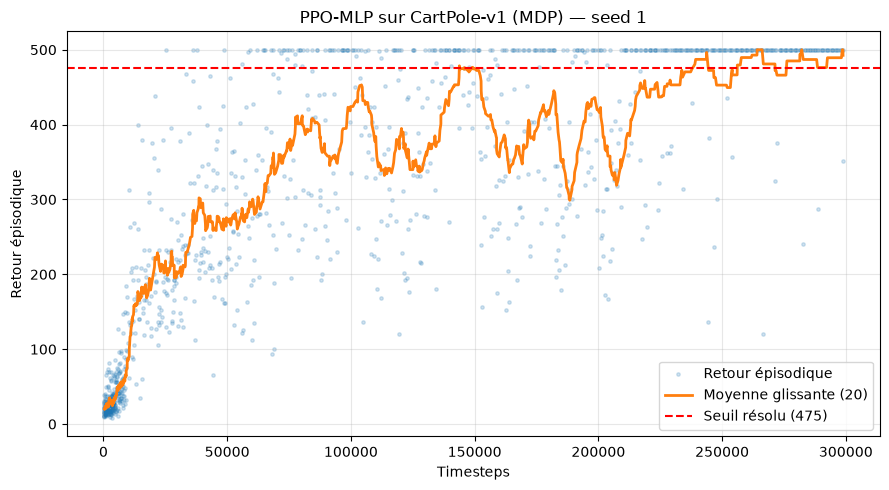

Figure → c:\Users\Pape Malick\works\ppo-recurrent-pomdp\results\csv\ppo_mlp_cartpole_full__seed1.png


In [23]:
fig, ax = plt.subplots(1, 1, figsize=(9, 5))
steps = np.array(history["step"])
returns = np.array(history["episodic_return"])
ax.scatter(steps, returns, s=6, alpha=0.2, label="Retour épisodique")
if len(returns) >= 20:
    smooth = np.convolve(returns, np.ones(20)/20, mode="valid")
    ax.plot(steps[19:], smooth, color="C1", linewidth=2, label="Moyenne glissante (20)")
ax.axhline(475, color="red", linestyle="--", label="Seuil résolu (475)")
ax.set_xlabel("Timesteps")
ax.set_ylabel("Retour épisodique")
ax.set_title(f"PPO-MLP sur CartPole-v1 (MDP) — seed {args.seed}")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
fig_path = ROOT / "results" / "csv" / f"{run_name}.png"
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=120)
plt.show()
print(f"Figure → {fig_path}")

## Sauvegarde des données pour l'analyse comparative (NB 04)

In [24]:
import pandas as pd
df = pd.DataFrame({"step": history["step"], "return": history["episodic_return"]})
df["config"] = "PPO-MLP / CartPole (MDP)"
csv_path = ROOT / "results" / "csv" / f"{run_name}.csv"
df.to_csv(csv_path, index=False)
print(f"CSV → {csv_path}")

# Sauvegarde du modèle
model_path = ROOT / "results" / "models" / f"{run_name}.pt"
model_path.parent.mkdir(parents=True, exist_ok=True)
torch.save(agent.state_dict(), model_path)
print(f"Modèle → {model_path}")

# Stats finales
print(f"\nRetour moyen sur les 50 derniers épisodes : {np.mean(returns[-50:]):.2f}")
if np.mean(returns[-50:]) >= 475:
    print("✅ CartPole-v1 résolu.")

CSV → c:\Users\Pape Malick\works\ppo-recurrent-pomdp\results\csv\ppo_mlp_cartpole_full__seed1.csv
Modèle → c:\Users\Pape Malick\works\ppo-recurrent-pomdp\results\models\ppo_mlp_cartpole_full__seed1.pt

Retour moyen sur les 50 derniers épisodes : 487.54
✅ CartPole-v1 résolu.
